In [67]:
from mscg import *

In [68]:
AA_traj = Trajectory('1nt/no_solvent_ions.trr', fmt='trr')
AA_traj.read_frame()
AA_traj.x.shape

(1476, 3)

In [69]:
from mscg.cli import cgmap

# map atomistic traj to CG traj
cgmap.main(map='map_dna.yaml', traj='no_solvent_ions.trr', out='CG_2_bead.lammpstrj')

In [70]:
CG_traj = Trajectory('CG_2_bead.lammpstrj', fmt='lammpstrj')
CG_traj.read_frame()
CG_traj.x.shape

(51, 3)

In [21]:
with open("CG_2_bead.lammpstrj") as f:
    for i, line in enumerate(f):
        print(line.strip())
        if i > 25: break

# 2. Check what the topology loaded
from mscg import Topology
top = Topology.read_file("no_solvent_ions_top.top")
print("Atom names:", top._names.get('atom'))
print("Atom types:", top._types.get('atom'))

ITEM: TIMESTEP
0
ITEM: NUMBER OF ATOMS
51
ITEM: BOX BOUNDS pp pp pp
0.000000e+00 7.683200e+01
0.000000e+00 7.338000e+01
0.000000e+00 1.207420e+02
ITEM: ATOMS id type x y z
1 1 38.343269 34.786095 25.393021
2 2 41.483837 35.453808 28.792631
3 3 44.169971 37.437588 32.687870
4 4 42.562275 40.577614 36.862888
5 3 40.508240 43.853256 40.053364
6 5 37.204903 44.898258 42.594910
7 3 32.727436 43.440224 45.109444
8 5 29.914394 39.978512 47.758747
9 3 29.659176 35.989830 50.470135
10 2 32.811020 32.338535 53.522064
11 9 38.078728 26.644543 51.300865
12 10 39.628193 25.722486 59.819218
13 5 41.192383 32.784370 61.906708
14 11 51.086838 33.132347 62.727493
15 12 51.245480 38.997589 67.471069
16 11 47.832745 43.891155 66.654884
17 12 42.848949 50.434994 67.507561
18 5 36.753929 43.883587 69.170090
Atom names: ['DT5', 'DG', 'DC', 'DA', 'DT', 'DT3', 'DA5', 'DA3', 'CY5A', 'CY5B', 'CY3A', 'CY3B']
Atom types: [ 0  1  2  3  2  4  2  4  2  1  8  9  4 10 11 10 11  4  1  3  2  2  1  3
  1  2  5  6  1  2  

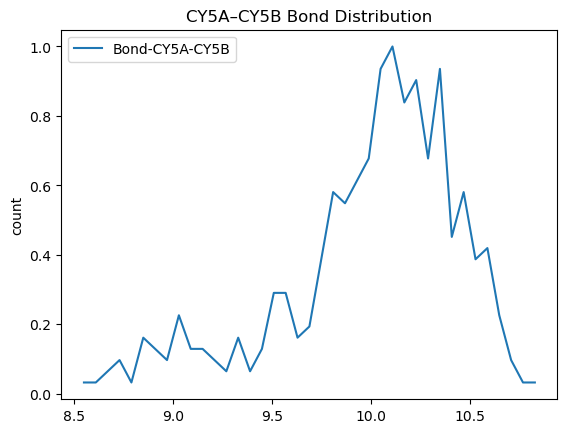

In [ ]:
from mscg.cli import cgib

hists = cgib.main(
    top   = "no_solvent_ions_top.top",
    traj  = "CG_2_bead.lammpstrj",
    cut   = 30,
    bond  = ['CY5A,CY5B,min=6,max=15,bins=75'],
    save  = 'return'
)

import matplotlib.pyplot as plt

for res in hists:
    data = res['data']
    plt.plot(data[:, 0], data[:, 1], label=res['name'])

plt.ylabel('count')
plt.title('CY5A–CY5B Bond Distribution')
plt.legend()
plt.show()

In [59]:
from mscg.cli import cgfm

cgfm.main(
    top     = "no_solvent_ions_top.top",
    traj    = "CG_2_bead.lammpstrj",
    cut     = 100.0,
    pair    = [
        'model=BSpline,type=DT:CY3A',
        'model=BSpline,type=DT:CY3B',
        'model=BSpline,type=DT:DT',
        'model=BSpline,type=DT:CY5A',
        'model=BSpline,type=DT:CY5B',
        'model=BSpline,type=DT:DC',
        'model=BSpline,type=CY3A:CY3B',
        'model=BSpline,type=CY3A:CY3A',
        'model=BSpline,type=CY3A:CY5A',
        'model=BSpline,type=CY3A:CY5B',
        'model=BSpline,type=CY3A:DC',
        'model=BSpline,type=CY3B:CY3B',
        'model=BSpline,type=CY3B:CY5A',
        'model=BSpline,type=CY3B:CY5B',
        'model=BSpline,type=CY3B:DC',
        'model=BSpline,type=CY5A:CY5B',
        'model=BSpline,type=CY5A:DC',
        'model=BSpline,type=CY5B:DC',
    ],
    bond    = [
        'model=BSpline,type=DT:CY3B,min=0,max=100,resolution=0.1',
        'model=BSpline,type=CY3B:CY3A',
        'model=BSpline,type=CY3A:DT',
        'model=BSpline,type=DT:CY5B',
        'model=BSpline,type=CY5B:CY5A',
        'model=BSpline,type=CY5A:DC'
    ],
    angle    = [
        ''
    ]
)

TypeError: sequence item 0: expected str instance, list found